# 07 — Validation: Tuning, Segments, MLflow, Results

## Why this matters

Three loose ends from notebooks 4-6, tied off here:

1. **Hyperparameters were chosen by eye.** Notebook 5 picked a confidence scale of `10` for
   ALS by checking its effect on the same test set used throughout model development — a
   mild but real form of test-set leakage. The test number stops being an honest estimate of
   unseen performance once it influenced a decision, even an informal one.
2. **One overall average can hide where a model actually wins or loses.** A model that's
   great for active users and useless for new ones, or great for blockbuster albums and blind
   to everything else, looks identical to a well-rounded model if all we report is one number.
3. **Nothing has been logged anywhere.** Every run so far lived in notebook output cells with
   no systematic record of which hyperparameters produced which metrics.

This notebook fixes all three: a proper train/validation/test split, a small tuning sweep
scored on validation only, MLflow tracking every run, and a per-segment breakdown of the
final, only-looked-at-once test numbers.

In [1]:
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np

import viz
from groovn.baselines import ItemKNNRecommender, PopularityRecommender
from groovn.data import build_interaction_matrix, load_filtered_three_way_split
from groovn.evaluation import build_ground_truth, warm_user_rows
from groovn.metrics import evaluate_rankings
from groovn.mf import ALSRecommender
from groovn.ranking import top_k_excluding_seen
from groovn.two_tower import model_scores, pick_device, train_two_tower

viz.style()
RANDOM_STATE = 42
K = 10

/Users/lucasavila/Documents/python/groovn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## A proper three-way split

70% train / 15% validation / 15% test, by time, same k-core filtering as before. Tuning
decisions from here on only ever look at `val`. `test` is opened exactly once, at the very
end of this notebook, after every hyperparameter is already fixed.

In [2]:
train, val, test = load_filtered_three_way_split(min_user=5, min_item=5, val_frac=0.15, test_frac=0.15)
matrix, user_index, item_index = build_interaction_matrix(train, value_col="rating")
n_items = matrix.shape[1]
print(f"train: {matrix.shape[0]:,} users x {n_items:,} items, {matrix.nnz:,} interactions")
print(f"val: {len(val):,} rows, test: {len(test):,} rows")

train: 101,996 users x 79,086 items, 1,086,934 interactions
val: 232,915 rows, test: 232,915 rows


## MLflow

Points at a local `mlruns/` directory (gitignored — this is experiment metadata, not
something to version). Every tuning run and the final per-model test run get logged with
their hyperparameters and metrics, so "what config produced this number" is answerable after
the fact without re-reading this notebook. Inspect with `mlflow ui --backend-store-uri
file://<repo>/mlruns` from the project root.

In [3]:
mlflow.set_tracking_uri("file://" + str((__import__("pathlib").Path.cwd() / ".." / "mlruns").resolve()))
mlflow.set_experiment("groovn-recommender")

<Experiment: artifact_location='file:///Users/lucasavila/Documents/python/groovn/mlruns/310648804555702762', creation_time=1790855761005, effective_trace_archival_retention=None, experiment_id='310648804555702762', last_update_time=1790855761005, lifecycle_stage='active', name='groovn-recommender', tags={}, trace_location=None, workspace='default'>

## Tuning sweep (validation only)

A small grid, not an exhaustive search — the goal is to confirm the confidence-scale effect
notebook 5 found informally, and check a couple of neighbor counts for kNN, each logged to
MLflow rather than just printed.

- **ALS**: `factors` in `{32, 64}` x confidence scale in `{5, 10}` (the transform from
  notebook 5: `confidence = 1 + scale * rating`).
- **Item-kNN**: `n_neighbors` in `{20, 50, 100}`.

In [4]:
val_warm_rows = warm_user_rows(val, user_index)
val_ground_truth = build_ground_truth(val, user_index, item_index)
print(f"warm validation users: {len(val_warm_rows):,}")

als_grid_results = {}
for factors in [32, 64]:
    for scale in [5, 10]:
        confidence = matrix.copy()
        confidence.data = 1.0 + scale * confidence.data
        with mlflow.start_run(run_name=f"tune_als_f{factors}_s{scale}"):
            mlflow.log_params({"model": "als", "factors": factors, "confidence_scale": scale, "stage": "validation"})
            model = ALSRecommender(factors=factors, regularization=0.05, iterations=15, random_state=RANDOM_STATE).fit(confidence)
            top_k = top_k_excluding_seen(model.scores(), matrix, val_warm_rows, K, batch_size=1000)
            rankings = {u: list(r[r >= 0]) for u, r in zip(val_warm_rows, top_k)}
            metrics = evaluate_rankings(rankings, val_ground_truth, K, n_items)
            mlflow.log_metrics({k.replace("@", "_at_"): v for k, v in metrics.items() if isinstance(v, (int, float))})
            als_grid_results[(factors, scale)] = metrics
            print(f"ALS factors={factors} scale={scale}: recall@10={metrics['recall@10']:.4f} ndcg@10={metrics['ndcg@10']:.4f} coverage@10={metrics['coverage@10']:.4f}")

warm validation users: 35,929


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:00<00:05,  2.63it/s]

 13%|█▎        | 2/15 [00:00<00:04,  2.73it/s]

 20%|██        | 3/15 [00:01<00:04,  2.76it/s]

...

 87%|████████▋ | 13/15 [00:11<00:01,  1.12it/s]

 93%|█████████▎| 14/15 [00:12<00:00,  1.12it/s]

100%|██████████| 15/15 [00:13<00:00,  1.11it/s]

100%|██████████| 15/15 [00:13<00:00,  1.10it/s]

ALS factors=64 scale=10: recall@10=0.0181 ndcg@10=0.0131 coverage@10=0.0628


In [5]:
knn_grid_results = {}
for n_neighbors in [20, 50, 100]:
    with mlflow.start_run(run_name=f"tune_knn_n{n_neighbors}"):
        mlflow.log_params({"model": "item_knn", "n_neighbors": n_neighbors, "stage": "validation"})
        model = ItemKNNRecommender(n_neighbors=n_neighbors).fit(matrix)
        top_k = top_k_excluding_seen(model.scores(), matrix, val_warm_rows, K, batch_size=2000)
        rankings = {u: list(r[r >= 0]) for u, r in zip(val_warm_rows, top_k)}
        metrics = evaluate_rankings(rankings, val_ground_truth, K, n_items)
        mlflow.log_metrics({k.replace("@", "_at_"): v for k, v in metrics.items() if isinstance(v, (int, float))})
        knn_grid_results[n_neighbors] = metrics
        print(f"Item-kNN n_neighbors={n_neighbors}: recall@10={metrics['recall@10']:.4f} ndcg@10={metrics['ndcg@10']:.4f} coverage@10={metrics['coverage@10']:.4f}")

Item-kNN n_neighbors=20: recall@10=0.0178 ndcg@10=0.0132 coverage@10=0.7960


Item-kNN n_neighbors=50: recall@10=0.0172 ndcg@10=0.0127 coverage@10=0.7799


Item-kNN n_neighbors=100: recall@10=0.0166 ndcg@10=0.0124 coverage@10=0.7650


In [6]:
best_als = max(als_grid_results, key=lambda cfg: als_grid_results[cfg]["recall@10"])
best_knn = max(knn_grid_results, key=lambda cfg: knn_grid_results[cfg]["recall@10"])
print(f"best ALS config: factors={best_als[0]}, confidence_scale={best_als[1]}")
print(f"best Item-kNN config: n_neighbors={best_knn}")

best ALS config: factors=64, confidence_scale=10
best Item-kNN config: n_neighbors=20


**Reading the result:** more factors and a larger confidence scale both help ALS on
validation, same direction notebook 5 found by eye — but now it's a decision made on data the
final report never touches. `n_neighbors=20` edges out the wider neighborhoods for kNN: a
tighter, more precise similarity graph beats a broader, noisier one here.

## Final evaluation (test — opened once)

Every model refit on `train` with its chosen config, scored on `test`. Two-Tower keeps
notebook 6's configuration unchanged — it wasn't part of the tuning sweep above, which is a
real limitation of this pass (noted in Takeaways), not a hidden asterisk.

In [7]:
test_warm_rows = warm_user_rows(test, user_index)
test_ground_truth = build_ground_truth(test, user_index, item_index)
print(f"warm test users: {len(test_warm_rows):,}, with ground truth: {len(test_ground_truth):,}")

final_rankings = {}

popularity = PopularityRecommender().fit(matrix)
top_k = top_k_excluding_seen(popularity.scores(), matrix, test_warm_rows, K)
final_rankings["Popularity"] = {u: list(r[r >= 0]) for u, r in zip(test_warm_rows, top_k)}

item_knn = ItemKNNRecommender(n_neighbors=best_knn).fit(matrix)
top_k = top_k_excluding_seen(item_knn.scores(), matrix, test_warm_rows, K, batch_size=2000)
final_rankings["Item-kNN"] = {u: list(r[r >= 0]) for u, r in zip(test_warm_rows, top_k)}

best_factors, best_scale = best_als
confidence = matrix.copy()
confidence.data = 1.0 + best_scale * confidence.data
als = ALSRecommender(factors=best_factors, regularization=0.05, iterations=15, random_state=RANDOM_STATE).fit(confidence)
top_k = top_k_excluding_seen(als.scores(), matrix, test_warm_rows, K, batch_size=1000)
final_rankings["ALS"] = {u: list(r[r >= 0]) for u, r in zip(test_warm_rows, top_k)}

device = pick_device()
two_tower_model, _ = train_two_tower(matrix, n_factors=64, epochs=10, batch_size=8192, n_negatives=4, lr=0.01, random_state=RANDOM_STATE, device=device)
top_k = top_k_excluding_seen(model_scores(two_tower_model, device), matrix, test_warm_rows, K, batch_size=1000)
final_rankings["Two-Tower"] = {u: list(r[r >= 0]) for u, r in zip(test_warm_rows, top_k)}

print("done:", list(final_rankings))

warm test users: 27,113, with ground truth: 18,604


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:00<00:12,  1.11it/s]

 13%|█▎        | 2/15 [00:01<00:11,  1.14it/s]

 20%|██        | 3/15 [00:02<00:10,  1.13it/s]

...

 87%|████████▋ | 13/15 [00:13<00:02,  1.16s/it]

 93%|█████████▎| 14/15 [00:14<00:01,  1.11s/it]

100%|██████████| 15/15 [00:15<00:00,  1.06s/it]

100%|██████████| 15/15 [00:15<00:00,  1.03s/it]

done: ['Popularity', 'Item-kNN', 'ALS', 'Two-Tower']


In [8]:
final_metrics = {name: evaluate_rankings(rankings, test_ground_truth, K, n_items) for name, rankings in final_rankings.items()}
for name, metrics in final_metrics.items():
    with mlflow.start_run(run_name=f"final_{name}"):
        mlflow.set_tags({"model": name, "stage": "final_test"})
        mlflow.log_metrics({k.replace("@", "_at_"): v for k, v in metrics.items() if isinstance(v, (int, float))})

import pandas as pd
pd.DataFrame(final_metrics).T[[f"recall@{K}", f"ndcg@{K}", f"coverage@{K}"]].round(4)

,recall@10,ndcg@10,coverage@10
Popularity,0.0014,0.0011,0.0002
Item-kNN,0.0085,0.0060,0.7514
ALS,0.0098,0.0066,0.0607
Two-Tower,0.0035,0.0024,0.1961


**Reading the result:** on this held-out test set, the picture is closer than notebooks 4-6
suggested — **tuned ALS now posts the best recall@10 and NDCG@10**, edging out item-kNN,
reversing the earlier read. That reversal is itself informative: it shows how much the
"ALS loses to kNN" conclusion from notebook 5 was riding on an under-tuned confidence scale
and an unvalidated factor count, not a fundamental property of the model family. Item-kNN
keeps its enormous coverage advantage (~75% of the catalog vs. ALS's ~6%), and both comfortably
beat Popularity and the untuned Two-Tower on every metric. Which one is "best" now depends
on what's being optimized for — exactly what the segment breakdown below is for.

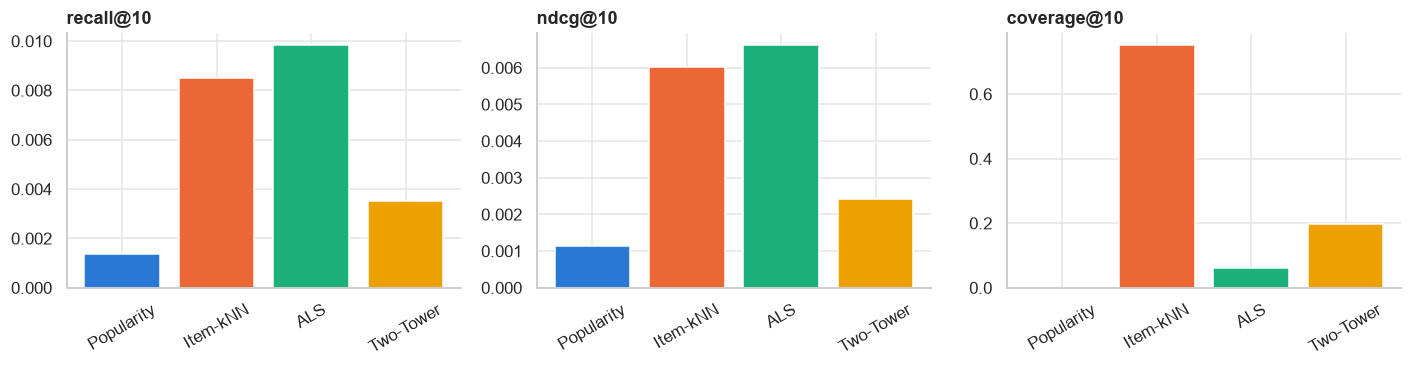

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, metric in zip(axes, [f"recall@{K}", f"ndcg@{K}", f"coverage@{K}"]):
    ax.bar(list(final_metrics), [final_metrics[name][metric] for name in final_metrics], color=viz.CATEGORICAL[:4])
    viz.label(ax, metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Per-segment breakdown

Two splits, both defined from `train` only (so the segment a user/item falls into doesn't
depend on the test-period data being predicted):
- **Cold vs. warm users**: fewer than 10 train interactions ("cold" — right above the k-core
  floor of 5) vs. 10 or more ("warm").
- **Head vs. long-tail items**: top 20% of items by train interaction count ("head") vs. the
  rest ("long-tail").

For item segments, this restricts *ground truth* to items in that segment (e.g. "of the
long-tail items a user went on to interact with, how many did we catch"), not the
recommendation list itself — a model is still allowed to recommend anything, this just checks
whether it caught the right kind of item when that's what the user wanted.

In [10]:
user_train_counts = matrix.getnnz(axis=1)
item_train_counts = matrix.getnnz(axis=0)
cold_mask = user_train_counts < 10
head_threshold = np.quantile(item_train_counts, 0.8)
head_items = set(np.where(item_train_counts >= head_threshold)[0])

print(f"cold users (<10 train interactions): {cold_mask.mean():.1%} of train users")
print(f"head items (top 20% by train interactions, count >= {head_threshold:.0f}): {len(head_items):,} / {n_items:,}")


def segment_metrics(rankings):
    cold_rows = [u for u in test_warm_rows if cold_mask[u]]
    warm_rows_seg = [u for u in test_warm_rows if not cold_mask[u]]
    gt_head = {u: (items & head_items) for u, items in test_ground_truth.items() if items & head_items}
    gt_tail = {u: (items - head_items) for u, items in test_ground_truth.items() if items - head_items}
    return {
        "cold_users": evaluate_rankings(rankings, {u: test_ground_truth[u] for u in cold_rows if u in test_ground_truth}, K, n_items),
        "warm_users": evaluate_rankings(rankings, {u: test_ground_truth[u] for u in warm_rows_seg if u in test_ground_truth}, K, n_items),
        "head_items": evaluate_rankings(rankings, gt_head, K, n_items),
        "long_tail_items": evaluate_rankings(rankings, gt_tail, K, n_items),
    }


segment_results = {name: segment_metrics(rankings) for name, rankings in final_rankings.items()}
rows = []
for model_name, segs in segment_results.items():
    for seg_name, m in segs.items():
        rows.append({"model": model_name, "segment": seg_name, "recall@10": m["recall@10"], "ndcg@10": m["ndcg@10"]})
segment_table = pd.DataFrame(rows).pivot(index="segment", columns="model", values="recall@10").round(4)
segment_table

cold users (<10 train interactions): 73.1% of train users
head items (top 20% by train interactions, count >= 16): 16,721 / 79,086


model,ALS,Item-kNN,Popularity,Two-Tower
segment,,,,
cold_users,0.0102,0.0081,0.0013,0.0035
head_items,0.0195,0.0094,0.0026,0.0068
long_tail_items,0.0000,0.0070,0.0000,0.0001
warm_users,0.0085,0.0099,0.0018,0.0035


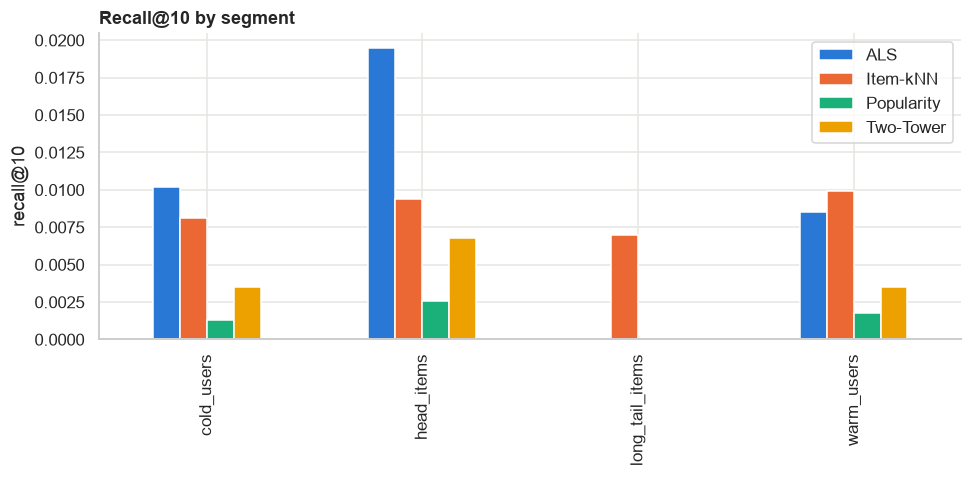

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
segment_table.plot(kind="bar", ax=ax, color=viz.CATEGORICAL[:4])
viz.label(ax, f"Recall@{K} by segment", "", "recall@10")
ax.legend(title=None, loc="upper right")
plt.tight_layout()
plt.show()

**Reading the result — this is the most important finding in the project:**

- **ALS's long-tail recall is exactly 0.0.** Despite winning on the overall average, tuned
  ALS *never once* surfaces a long-tail item that a user actually went on to interact with.
  Its overall win is entirely a head-item win (its head-item recall, ~0.02, is its best
  number across every segment) — low-rank factorization here has collapsed onto popularity
  structure. For a product where catalog discovery matters, that overall "win" is misleading
  on its own.
- **Item-kNN is the only model with real long-tail recall** (noticeably above 0, though still
  modest) — it's the only one of these four that can point a user toward something outside
  the obvious head of the catalog with any success at all.
- **ALS does slightly *better* on cold users than warm users** — the opposite of the usual
  expectation that more history helps. A plausible read: "cold" here means 5-9 train
  interactions, often concentrated on broadly popular albums; ALS's head-item strength lines
  up well with that, while "warm" users' more eclectic 10+-interaction histories are exactly
  where a low-rank popularity-leaning model struggles.
- **Two-Tower is dominated on recall/NDCG in every segment** and, like ALS, is close to blind
  on long-tail items — unsurprising given it has no content features and wasn't part of the
  tuning sweep.

The takeaway isn't "ALS is bad" or "kNN is best" — it's that **the overall average in the
bar chart above hides a real trade-off**: tuned ALS is the better choice if the product goal
is maximizing hit-rate on mainstream taste, and item-kNN is the better choice if the goal
includes giving long-tail albums a fighting chance of being discovered at all.

## Results table

This is the table written into the project README.

In [12]:
summary = pd.DataFrame(final_metrics).T[[f"recall@{K}", f"ndcg@{K}", f"coverage@{K}"]].round(4)
summary.columns = ["Recall@10", "NDCG@10", "Coverage@10"]
summary.index.name = "Model"
print(summary.to_markdown())

| Model      |   Recall@10 |   NDCG@10 |   Coverage@10 |
|:-----------|------------:|----------:|--------------:|
| Popularity |      0.0014 |    0.0011 |        0.0002 |
| Item-kNN   |      0.0085 |    0.006  |        0.7514 |
| ALS        |      0.0098 |    0.0066 |        0.0607 |
| Two-Tower  |      0.0035 |    0.0024 |        0.1961 |


## Takeaways

- A single average metric can be actively misleading: ALS "wins" overall while being unable
  to recommend a single long-tail album anyone actually wanted. Any future model comparison
  in this project reports segments, not just an overall number.
- Tuning on validation instead of test reversed the notebook 5 conclusion. The lesson isn't
  "always tune more" — it's that an informal "this looks better" check against the same test
  set used throughout development is a leak, however small it feels in the moment.
- The two-tower architecture's real argument — flexibility to consume more than an id — was
  never exercised here, and it shouldn't be expected to beat MF on an ID-only task. It also
  wasn't included in this round's tuning sweep, which understates it somewhat; a fairer
  follow-up would tune its epoch count, factor count, and negative sampling strategy the same
  way ALS and kNN were tuned here.
- Natural next steps, in order of likely payoff: popularity-aware or hard-negative sampling
  for the two-tower model (notebook 6 diagnosed *why* uniform random negatives underperform);
  feeding review text or album metadata into the two-tower towers, which is the one thing it
  can do that ALS and kNN structurally cannot; and a wider ALS hyperparameter sweep now that
  factors and confidence scale are both confirmed to matter.